In [1]:
import pandas as pd
import numpy as np

In [ ]:

"Modifications_obs_raw_by_day.ods"

In [2]:
# Install required library for reading ODS files
import subprocess
import sys

try:
    import odf
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "odfpy", "-q"])

# Load the ODS file
file_path = "Modifications_obs_raw_by_day.ods"
df = pd.read_excel(file_path, engine='odf', sheet_name=0)

print(f"Data shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head(10)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Data shape: (19866, 4)

Column names and types:
insertion_day              str
network_name               str
daily_insertions         int64
cumulative_insertions    int64
dtype: object

First few rows:


,insertion_day,network_name,daily_insertions,cumulative_insertions
0,2011-08-29 00:00:00.000000,AGRI,113950,113950
1,2011-08-29 00:00:00.000000,BCH,2614940,2614940
2,2011-08-29 00:00:00.000000,EC,51536071,51536071
3,2011-08-29 00:00:00.000000,ENV-AQN,15668915,15668915
4,2011-08-29 00:00:00.000000,ENV-ASP,493371,493371
5,2011-08-29 00:00:00.000000,FLNRO-FERN,1661190,1661190
6,2011-08-29 00:00:00.000000,FLNRO-WMB,133166481,133166481
7,2011-08-29 00:00:00.000000,MoTIe,154052514,154052514
8,2011-08-29 00:00:00.000000,MoTIm,4566008,4566008
9,2011-08-29 00:00:00.000000,RT,146468,146468


In [3]:
import matplotlib.pyplot as plt

# Convert insertion_day to datetime
df['insertion_day'] = pd.to_datetime(df['insertion_day'])

# Extract year
df['year'] = df['insertion_day'].dt.year

# Calculate yearly sums by network
yearly_sums = df.groupby(['year', 'network_name'])[
    'daily_insertions'].sum().reset_index()

print("Yearly sums by network:")
print(yearly_sums.head(20))
print(f"\nTotal rows: {len(yearly_sums)}")
print(
    f"Years covered: {yearly_sums['year'].min()} to {yearly_sums['year'].max()}")
print(f"Networks: {yearly_sums['network_name'].unique()}")

Yearly sums by network:
    year network_name  daily_insertions
0   2011         AGRI            113950
1   2011         ARDA           3390694
2   2011          BCH           2614940
3   2011           EC          51536071
4   2011      ENV-AQN          15668915
5   2011      ENV-ASP            493371
6   2011   FLNRO-FERN           1661190
7   2011    FLNRO-WMB         133166481
8   2011         FRBC           3104710
9   2011        MoTIe         154052514
10  2011        MoTIm           4566008
11  2011           RT            146468
12  2012          BCH              3912
13  2012           EC          47194413
14  2012       EC_raw           7358200
15  2012      ENV-AQN                 3
16  2012      ENV-ASP              1016
17  2012    FLNRO-WMB              3175
18  2012         FRBC               156
19  2012        MoTIe              2601

Total rows: 133
Years covered: 2011 to 2026
Networks: <ArrowStringArray>
[              'AGRI',               'ARDA',                'B

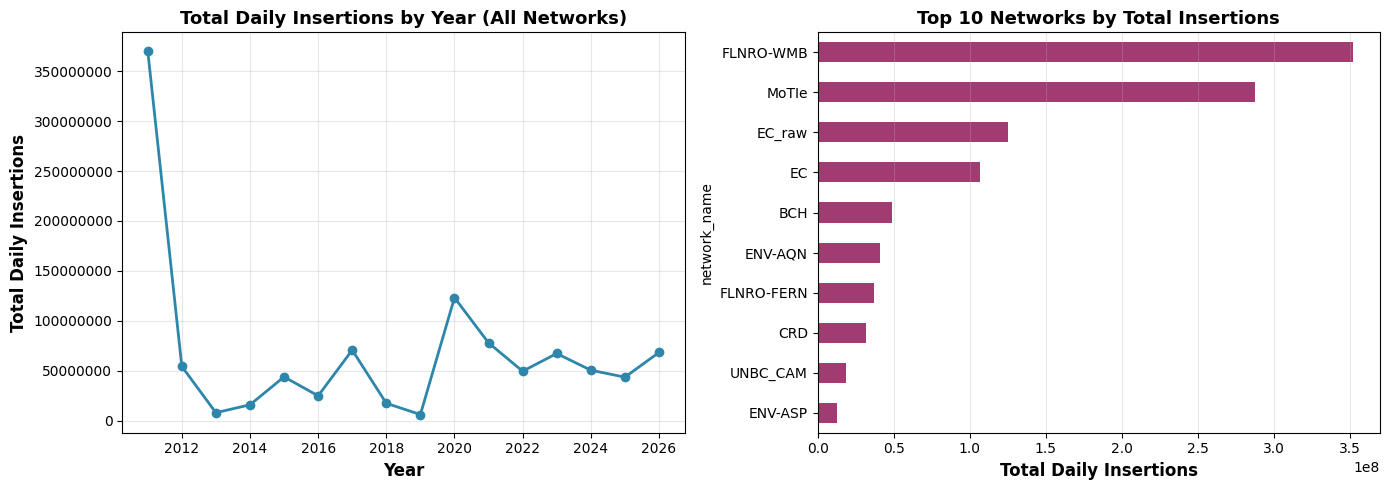


Total insertions across all years: 1,094,889,794
Average insertions per year: 68,430,612


In [4]:
# Plot 1: Total insertions per year (all networks combined)
yearly_total = df.groupby('year')['daily_insertions'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Line plot - total insertions per year
ax1.plot(yearly_total.index, yearly_total.values, marker='o',
         linewidth=2, markersize=6, color='#2E86AB')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Daily Insertions', fontsize=12, fontweight='bold')
ax1.set_title('Total Daily Insertions by Year (All Networks)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')

# Bar plot - top 10 networks by total insertions
top_networks = df.groupby('network_name')[
    'daily_insertions'].sum().nlargest(10).sort_values()
top_networks.plot(kind='barh', ax=ax2, color='#A23B72')
ax2.set_xlabel('Total Daily Insertions', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 Networks by Total Insertions',
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTotal insertions across all years: {yearly_total.sum():,}")
print(f"Average insertions per year: {yearly_total.mean():,.0f}")

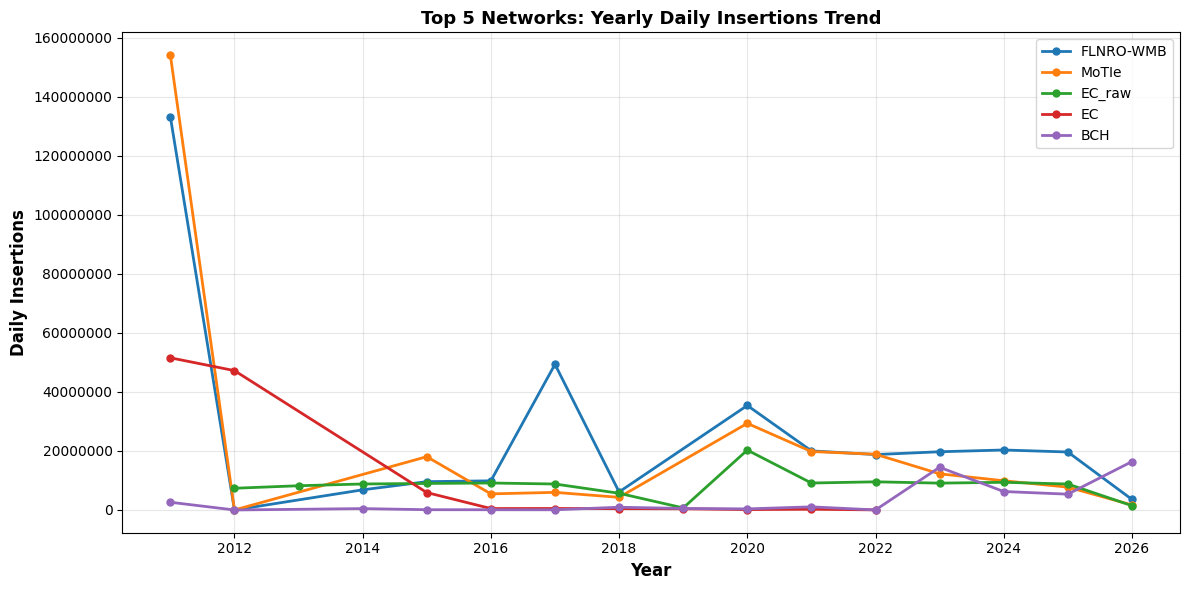


Top 5 Networks: ['FLNRO-WMB', 'MoTIe', 'EC_raw', 'EC', 'BCH']


In [5]:
# Plot 2: Top networks over time
top_5_networks = df.groupby('network_name')[
    'daily_insertions'].sum().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for network in top_5_networks:
    network_data = yearly_sums[yearly_sums['network_name'] == network]
    ax.plot(network_data['year'], network_data['daily_insertions'],
            marker='o', linewidth=2, markersize=5, label=network)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Insertions', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Networks: Yearly Daily Insertions Trend',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Networks: {top_5_networks}")

In [6]:
# First, let's check available sheets in the ODS file
import odf.opendocument
import odf.table

doc = odf.opendocument.load(file_path)
sheets = [sheet.getAttribute(
    "name") for sheet in doc.spreadsheet.getElementsByType(odf.table.Table)]
print("Available sheets in the ODS file:")
for i, sheet in enumerate(sheets, 1):
    print(f"  {i}. {sheet}")

Available sheets in the ODS file:
  1. Insertions_Per_Day_By_Network
  2. Pivot Table_Insertions_Per_Day_By_Network_1
  3. Insertions_Per_Day_2Years
  4. Pivot Table_Insertions_Per_Day_2Years_1


In [7]:
# Load the Insertions_Per_Day_2Years sheet
df_2years = pd.read_excel(file_path, engine='odf',
                          sheet_name='Insertions_Per_Day_2Years')

print(f"Data shape: {df_2years.shape}")
print(f"\nColumn names:")
print(df_2years.columns.tolist())
print(f"\nFirst few rows:")
print(df_2years.head(10))
print(f"\nData types:")
print(df_2years.dtypes)

Data shape: (4781, 4)

Column names:
['insertion_day', 'network_name', 'daily_insertions', 'cumulative_insertions']

First few rows:
                insertion_day        network_name  daily_insertions  \
0  2024-03-02 00:00:00.000000  DFO_CCG_lighthouse               277   
1  2024-03-02 00:00:00.000000              EC_raw             23414   
2  2024-03-02 00:00:00.000000             ENV-ASP              2598   
3  2024-03-02 00:00:00.000000          FLNRO-FERN               274   
4  2024-03-02 00:00:00.000000           FLNRO-WMB             49245   
5  2024-03-02 00:00:00.000000               MoTIe             28967   
6  2024-03-02 00:00:00.000000                  RT               177   
7  2024-03-03 00:00:00.000000  DFO_CCG_lighthouse               166   
8  2024-03-03 00:00:00.000000              EC_raw             19345   
9  2024-03-03 00:00:00.000000             ENV-AQN             18219   

   cumulative_insertions  
0                    277  
1                  23414  
2   

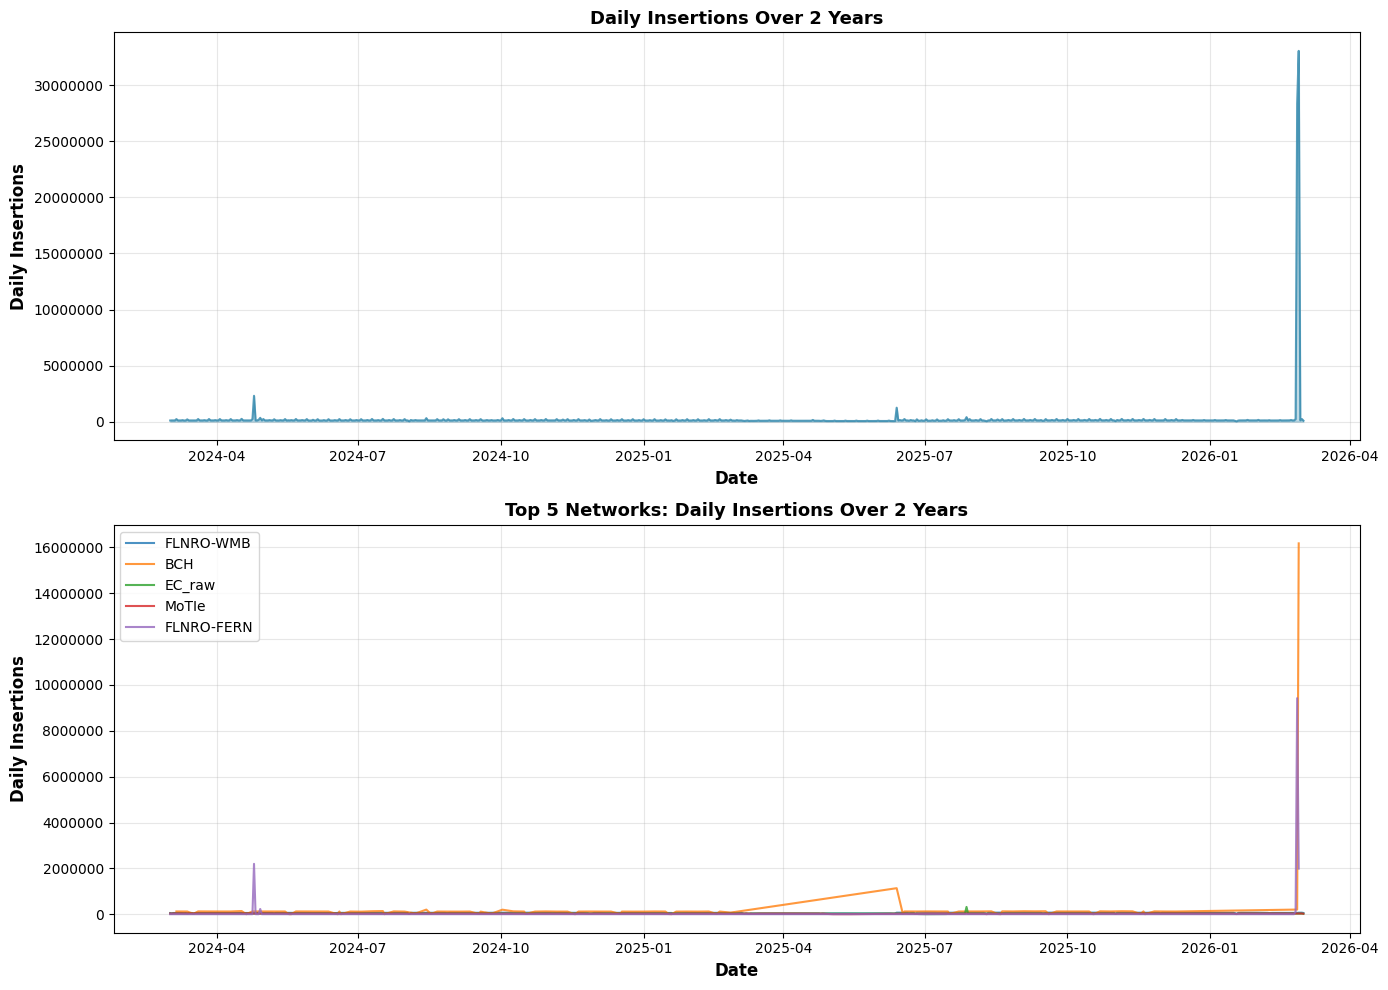


Date range: 2024-03-02 to 2026-03-02
Total days: 731
Average daily insertions: 212,314
Max daily insertions: 33,059,369 on 2026-02-27
Min daily insertions: 26,032 on 2026-01-18
Total insertions: 155,201,214


In [8]:
# Convert insertion_day to datetime
df_2years['insertion_day'] = pd.to_datetime(df_2years['insertion_day'])

# Aggregate daily insertions by day (sum across all networks)
daily_total = df_2years.groupby('insertion_day')[
    'daily_insertions'].sum().sort_index()

# Create plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: All daily insertions
ax1.plot(daily_total.index, daily_total.values,
         linewidth=1.5, color='#2E86AB', alpha=0.8)
ax1.fill_between(daily_total.index, daily_total.values,
                 alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Daily Insertions', fontsize=12, fontweight='bold')
ax1.set_title('Daily Insertions Over 2 Years', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')

# Plot 2: Daily insertions by top networks
top_networks_2y = df_2years.groupby(
    'network_name')['daily_insertions'].sum().nlargest(5).index.tolist()
for network in top_networks_2y:
    network_data = df_2years[df_2years['network_name']
                             == network].sort_values('insertion_day')
    daily_network = network_data.groupby('insertion_day')[
        'daily_insertions'].sum()
    ax2.plot(daily_network.index, daily_network.values,
             linewidth=1.5, label=network, alpha=0.8)

ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Daily Insertions', fontsize=12, fontweight='bold')
ax2.set_title('Top 5 Networks: Daily Insertions Over 2 Years',
              fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print(
    f"\nDate range: {daily_total.index.min().date()} to {daily_total.index.max().date()}")
print(f"Total days: {len(daily_total)}")
print(f"Average daily insertions: {daily_total.mean():,.0f}")
print(
    f"Max daily insertions: {daily_total.max():,.0f} on {daily_total.idxmax().date()}")
print(
    f"Min daily insertions: {daily_total.min():,.0f} on {daily_total.idxmin().date()}")
print(f"Total insertions: {daily_total.sum():,.0f}")

In [9]:
# Load the Pivot Table_Insertions_Per_Day_By_Network_1 sheet
pivot_table = pd.read_excel(
    file_path, engine='odf', sheet_name='Pivot Table_Insertions_Per_Day_By_Network_1')

print(f"Pivot table shape: {pivot_table.shape}")
print(f"\nColumn names:")
print(pivot_table.columns.tolist())
print(f"\nFirst few rows:")
print(pivot_table.head(15))
print(f"\nData types:")
print(pivot_table.dtypes)

Pivot table shape: (4766, 25)

Column names:
['Sum - daily_insertions', 'network_name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']

First few rows:
        Sum - daily_insertions network_name Unnamed: 2 Unnamed: 3 Unnamed: 4  \
0                insertion_day         AGRI        ARD       ARDA      BC-TS   
1   2011-08-29 00:00:00.000000       113950        NaN        NaN        NaN   
2   2011-10-17 00:00:00.000000          NaN        NaN        NaN        NaN   
3   2011-10-27 00:00:00.000000          NaN        NaN       2670        NaN   
4   2011-10-28 00:00:00.000000          NaN        NaN    3080361        NaN   
5   2011-11-07 00:00:00.000000          NaN        NaN     113830        NaN  

In [10]:
# Get basic info about the pivot table
print(f"Pivot table shape: {pivot_table.shape}")
print(f"\nColumn names ({len(pivot_table.columns)}):")
for i, col in enumerate(pivot_table.columns):
    print(f"  {i+1}. {col}")

# Check for NaN values and data structure
print(f"\nFirst column (index): {pivot_table.iloc[:5, 0].tolist()}")
print(f"\nData info:")
print(f"  - Rows: {len(pivot_table)}")
print(f"  - Columns: {len(pivot_table.columns)}")
print(f"  - Non-null values per column:")
print(pivot_table.isnull().sum())

Pivot table shape: (4766, 25)

Column names (25):
  1. Sum - daily_insertions
  2. network_name
  3. Unnamed: 2
  4. Unnamed: 3
  5. Unnamed: 4
  6. Unnamed: 5
  7. Unnamed: 6
  8. Unnamed: 7
  9. Unnamed: 8
  10. Unnamed: 9
  11. Unnamed: 10
  12. Unnamed: 11
  13. Unnamed: 12
  14. Unnamed: 13
  15. Unnamed: 14
  16. Unnamed: 15
  17. Unnamed: 16
  18. Unnamed: 17
  19. Unnamed: 18
  20. Unnamed: 19
  21. Unnamed: 20
  22. Unnamed: 21
  23. Unnamed: 22
  24. Unnamed: 23
  25. Unnamed: 24

First column (index): ['insertion_day', '2011-08-29 00:00:00.000000', '2011-10-17 00:00:00.000000', '2011-10-27 00:00:00.000000', '2011-10-28 00:00:00.000000']

Data info:
  - Rows: 4766
  - Columns: 25
  - Non-null values per column:
Sum - daily_insertions       0
network_name              4760
Unnamed: 2                4763
Unnamed: 3                4759
Unnamed: 4                4763
Unnamed: 5                4459
Unnamed: 6                4762
Unnamed: 7                4736
Unnamed: 8           

In [11]:
# Reload the pivot table with first row as header and first column as index
pivot_table = pd.read_excel(file_path, engine='odf', sheet_name='Pivot Table_Insertions_Per_Day_By_Network_1',
                            header=0, index_col=0)

# The first row (index_col=0) becomes the index - rename it
pivot_table.index.name = 'insertion_day'

# Convert index to datetime if it's not already
try:
    pivot_table.index = pd.to_datetime(pivot_table.index)
except:
    pass

print(f"Pivot table shape: {pivot_table.shape}")
print(f"\nNetwork columns ({len(pivot_table.columns)}):")
print(pivot_table.columns.tolist()[:10], "...")
print(f"\nIndex (dates):")
print(f"  From: {pivot_table.index.min()}")
print(f"  To: {pivot_table.index.max()}")
print(f"  Total dates: {len(pivot_table)}")
print(f"\nFirst few rows and columns:")
print(pivot_table.iloc[:5, :5])

Pivot table shape: (4766, 24)

Network columns (24):
['network_name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'] ...

Index (dates):
  From: 2011-08-29 00:00:00.000000
  To: insertion_day
  Total dates: 4766

First few rows and columns:
                           network_name Unnamed: 2 Unnamed: 3 Unnamed: 4  \
insertion_day                                                              
insertion_day                      AGRI        ARD       ARDA      BC-TS   
2011-08-29 00:00:00.000000       113950        NaN        NaN        NaN   
2011-10-17 00:00:00.000000          NaN        NaN        NaN        NaN   
2011-10-27 00:00:00.000000          NaN        NaN       2670        NaN   
2011-10-28 00:00:00.000000          NaN        NaN    3080361        NaN   

                           Unnamed: 5  
insertion_day                          
insertion_day                     BCH  
2011-08-29 00:00:00.000000

/tmp/ipykernel_75112/3111180140.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pivot_table.index = pd.to_datetime(pivot_table.index)


In [ ]:
# Properly load the pivot table 
pivot_raw = pd.read_excel(file_path, engine='odf', sheet_name='Pivot Table_Insertions_Per_Day_By_Network_1', header=None)

# First row contains headers (network names)
headers = pivot_raw.iloc[0, 1:].values  # Skip first column
data_rows = pivot_raw.iloc[2:, :].copy()  # Skip first two rows

# Filter out rows where first column is not a date or is text like "Total Result"
date_col = data_rows.iloc[:, 0]
valid_rows = []
for idx, val in enumerate(date_col):
    try:
        pd.to_datetime(val)
        valid_rows.append(idx)
    except:
        pass

# Extract valid rows
pivot_table = data_rows.iloc[valid_rows, 1:].copy()
pivot_table.columns = headers
pivot_table.index = pd.to_datetime(data_rows.iloc[valid_rows, 0].values)
pivot_table.index.name = 'insertion_day'

# Convert all values to numeric
pivot_table = pivot_table.apply(pd.to_numeric, errors='coerce')

# Drop columns that are all NaN
pivot_table = pivot_table.dropna(axis=1, how='all')

print(f"Pivot table shape: {pivot_table.shape}")
print(f"\nNetworks ({len(pivot_table.columns)}):")
print(list(pivot_table.columns))
print(f"\nDate range: {pivot_table.index.min().date()} to {pivot_table.index.max().date()}")
print(f"\nTotal insertions per network (top 10):")
print(pivot_table.sum().nlargest(10))

ValueError: time data "Total Result" doesn't match format "%Y-%m-%d %H:%M:%S.%f". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.